# Romanian ASR Whisper Fine-Tuning

This notebook fine-tunes `openai/whisper-small` for Romanian ASR using the prepared train/validation/test split from the local project.

Expected project structure after upload/unzip:

```text
romanian-asr-whisper/
  src/
    train_whisper.py
    evaluate_baseline.py
  data/
    raw/
      common_voice/
        cv-corpus-25.0-2026-03-09/
          ro/
            clips/
  data/
    processed/
      train.csv
      validation.csv
      test.csv
```

The split is assumed to be the cluster-balanced, speaker-disjoint split generated locally.

## 0. Runtime setup

In Colab, go to:

```text
Runtime -> Change runtime type -> GPU
```

A T4 GPU is enough for a first run. A100/L4 is better if available.

In [ ]:
!nvidia-smi

## 1. Mount Google Drive

Put your zipped project in Google Drive, for example:

```text
MyDrive/romanian-asr-whisper.zip
```

Recommended zip contents:
- `src/`
- `data/processed/`
- `data/raw/common_voice/cv-corpus-25.0-2026-03-09/ro/clips/`
- `data/raw/common_voice/cv-corpus-25.0-2026-03-09/ro/*.tsv`

Do not include `.venv`, `models/`, `wandb/`, or old checkpoints.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Unzip project

Change `ZIP_PATH` if your zip is stored somewhere else.

In [ ]:
from pathlib import Path
import shutil

ZIP_PATH = Path("/content/drive/MyDrive/romanian-asr-whisper.zip")
PROJECT_DIR = Path("/content/romanian-asr-whisper")

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)

assert ZIP_PATH.exists(), f"Zip file not found: {ZIP_PATH}"

!unzip -q "{ZIP_PATH}" -d /content/

assert PROJECT_DIR.exists(), f"Project directory not found after unzip: {PROJECT_DIR}"

%cd /content/romanian-asr-whisper
!find . -maxdepth 3 -type f | head -40

/content/romanian-asr-whisper
./.gitignore
./requirements.txt
./README.md
./.DS_Store
./data/raw/.DS_Store
./data/README.md
./data/processed/metadata_with_clusters_and_split.csv
./data/processed/validation.csv
./data/processed/common_voice_metadata_with_embeddings.csv
./data/processed/test.csv
./data/processed/common_voice_embeddings.npy
./data/processed/train.csv
./data/processed/common_voice_metadata.csv
./data/.DS_Store
./.idea/.gitignore
./.idea/romanian-asr-whisper.iml
./.idea/modules.xml
./.idea/workspace.xml
./.idea/misc.xml
./.idea/inspectionProfiles/profiles_settings.xml
./.idea/inspectionProfiles/Project_Default.xml
./src/cluster_and_split.py
./src/extract_embeddings.py
./src/app.py
./src/prepare_personal_metadata.py
./src/evaluate_baseline.py
./src/analyze_cluster_metadata.py
./src/train_whisper.py
./src/prepare_common_voice.py
./src/evaluate_finetuned.py
./src/select_k_for_clustering.py
./results/cluster_distribution.csv
./results/cluster_metadata_analysis/cluster_age_distr

## 3. Install dependencies

In [10]:
!apt-get update -qq
!apt-get install -y -qq ffmpeg

!pip install -q --upgrade pip
!pip install -q \
  transformers \
  datasets \
  accelerate \
  evaluate \
  jiwer \
  librosa \
  soundfile \
  pandas \
  numpy \
  scikit-learn \
  tqdm \
  safetensors

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.0 MB/s eta 0:00:00


## 4. Verify files

This checks that the CSV files exist and that the audio paths inside them resolve correctly.

In [11]:
from pathlib import Path
import pandas as pd

for split in ["train", "validation", "test"]:
    csv_path = Path(f"data/processed/{split}.csv")
    assert csv_path.exists(), f"Missing {csv_path}"

    df = pd.read_csv(csv_path)
    print(split)
    print("samples:", len(df))
    print("hours:", df["duration_seconds"].sum() / 3600)
    print("first audio path:", df.iloc[0]["audio_path"])
    print("first audio exists:", Path(df.iloc[0]["audio_path"]).exists())
    print()

    missing = df[~df["audio_path"].apply(lambda p: Path(p).exists())]
    assert len(missing) == 0, f"{split} has {len(missing)} missing audio files"

train
samples: 3450
hours: 4.000466111111111
first audio path: data/raw/common_voice/cv-corpus-25.0-2026-03-09/ro/clips/common_voice_ro_40018473.mp3
first audio exists: True

validation
samples: 429
hours: 0.5010697222222222
first audio path: data/raw/common_voice/cv-corpus-25.0-2026-03-09/ro/clips/common_voice_ro_20821552.mp3
first audio exists: True

test
samples: 408
hours: 0.5000227777777777
first audio path: data/raw/common_voice/cv-corpus-25.0-2026-03-09/ro/clips/common_voice_ro_30534136.mp3
first audio exists: True



## 5. Optional: inspect split distribution

In [12]:
for split in ["train", "validation", "test"]:
    df = pd.read_csv(f"data/processed/{split}.csv")
    print("=" * 80)
    print(split)
    print("samples:", len(df))
    print("hours:", round(df["duration_seconds"].sum() / 3600, 4))
    print("speakers:", df["speaker_id"].nunique())
    print("clusters:", sorted(df["cluster"].unique().tolist()))

train
samples: 3450
hours: 4.0005
speakers: 163
clusters: [0, 1, 2]
validation
samples: 429
hours: 0.5011
speakers: 71
clusters: [0, 1, 2]
test
samples: 408
hours: 0.5
speakers: 71
clusters: [0, 1, 2]


In [16]:
!mkdir -p /content/drive/MyDrive/romanian-asr-results

## 6. Smoke test training

This runs a very small training job to confirm that CUDA training works.

In [18]:
!rm -rf /content/drive/MyDrive/romanian-asr-results/smoke-test

!python src/train_whisper.py \
  --model-name openai/whisper-small \
  --output-dir /content/drive/MyDrive/romanian-asr-results/smoke-test \
  --max-train-samples 16 \
  --max-validation-samples 8 \
  --num-train-epochs 1 \
  --train-batch-size 2 \
  --eval-batch-size 2 \
  --gradient-accumulation-steps 2 \
  --learning-rate 1e-5 \
  --warmup-steps 5 \
  --logging-steps 1 \
  --eval-steps 100 \
  --save-steps 100 \
  --generation-max-length 64 \
  --gradient-checkpointing

Loading datasets...
Train samples: 16
Validation samples: 8
Loading processor and model: openai/whisper-small
Loading weights: 100% 479/479 [00:00<00:00, 584.53it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]
Enabling gradient checkpointing...
Preparing train dataset...
Preparing train data: 100% 16/16 [00:02<00:00,  7.49 examples/s]
Preparing validation dataset...
Preparing validation data: 100% 8/8 [00:00<00:00, 47.18 examples/s]
Starting training...
{'loss': '2.185', 'grad_norm': 'inf', 'learning_rate': '0', 'epoch': '0.25'}
{'loss': '2.422', 'grad_norm': 'inf', 'learning_rate': '2e-06', 'epoch': '0.5'}
{'loss': '2.957', 'grad_norm': 'inf', 'learning_rate': '4e-06', 'epoch': '0.75'}
{'loss': '2.142', 'grad_norm': '62.47', 'learning_rate': '6e-06', 'epoch': '1'}
100% 4/4 [00:06<00:00,  1.30s/it]
Writing model shards:   0% 0/1 [00:00<?, ?it/s]
Writing model shards: 100% 1/1 [00:04<00:00,  4.52s/it]
{'train_runtime': '29.53', 'train_samples_per_second': '0

In [15]:
!find /content/drive/MyDrive/whisper-small-ro-smoke-test -maxdepth 2 -type f | head -30
!cat /content/drive/MyDrive/whisper-small-ro-smoke-test/validation_metrics.txt

/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/config.json
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/generation_config.json
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/model.safetensors
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/tokenizer_config.json
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/tokenizer.json
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/processor_config.json
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/training_args.bin
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/optimizer.pt
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/scheduler.pt
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/scaler.pt
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/rng_state.pth
/content/drive/MyDrive/whisper-small-ro-smoke-test/checkpoint-4/trainer_state.json
/content/drive/MyDrive/whisper-sm

## 7. Full fine-tuning run

This is the main training run.

Suggested first configuration for Colab T4:

```text
batch size = 4
gradient accumulation = 4
effective batch size = 16
epochs = 3
learning rate = 1e-5
```

If you get CUDA out-of-memory, reduce `--train-batch-size` and `--eval-batch-size` to `2`, and increase `--gradient-accumulation-steps` to `8`.

In [19]:
!mkdir -p /content/drive/MyDrive/romanian-asr-results

!rm -rf /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs

!python src/train_whisper.py \
  --model-name openai/whisper-small \
  --output-dir /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs \
  --num-train-epochs 2 \
  --train-batch-size 4 \
  --eval-batch-size 4 \
  --gradient-accumulation-steps 4 \
  --learning-rate 5e-6 \
  --warmup-steps 50 \
  --logging-steps 25 \
  --eval-steps 200 \
  --save-steps 200 \
  --generation-max-length 225 \
  --gradient-checkpointing

Loading datasets...
Train samples: 3450
Validation samples: 429
Loading processor and model: openai/whisper-small
Loading weights: 100% 479/479 [00:00<00:00, 577.42it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]
Enabling gradient checkpointing...
Preparing train dataset...
Preparing train data: 100% 3450/3450 [01:29<00:00, 38.51 examples/s]
Preparing validation dataset...
Preparing validation data: 100% 429/429 [00:10<00:00, 41.72 examples/s]
Starting training...
{'loss': '4.082', 'grad_norm': '54.58', 'learning_rate': '2.4e-06', 'epoch': '0.1159'}
{'loss': '2.217', 'grad_norm': '39.67', 'learning_rate': '4.9e-06', 'epoch': '0.2317'}
{'loss': '1.395', 'grad_norm': '43.46', 'learning_rate': '4.686e-06', 'epoch': '0.3476'}
{'loss': '1.109', 'grad_norm': '31.23', 'learning_rate': '4.359e-06', 'epoch': '0.4635'}
{'loss': '1.271', 'grad_norm': '47.61', 'learning_rate': '4.031e-06', 'epoch': '0.5794'}
{'loss': '0.996', 'grad_norm': '59.57', 'learning_rate': '3.

In [20]:
!find /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs -maxdepth 2 -type d -print
!ls /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
!cat /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs/validation_metrics.txt

/content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
/content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs/checkpoint-400
/content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs/checkpoint-432
checkpoint-400		model.safetensors      training_args.bin
checkpoint-432		processor_config.json  validation_metrics.txt
config.json		tokenizer_config.json
generation_config.json	tokenizer.json
epoch: 2.0
eval_cer: 0.054411847198070344
eval_loss: 0.24741461873054504
eval_runtime: 179.2205
eval_samples_per_second: 2.394
eval_steps_per_second: 0.603
eval_wer: 0.18351063829787234


## 8. Evaluate fine-tuned model on the fixed test set

This evaluates the fine-tuned model on the same `test.csv` used for the baseline.

In [25]:
# SMOKE TEST
!python src/evaluate_baseline.py \
  --model-name /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs \
  --test-csv data/processed/test.csv \
  --output-csv results/finetuned_predictions_2epochs_final_smoke.csv \
  --metrics-csv results/finetuned_metrics_2epochs_final_smoke.csv \
  --max-samples 5

Using device: cuda
Evaluating model: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Test CSV: data/processed/test.csv
Samples: 5
Loading processor: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Loading model: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Loading weights: 100% 479/479 [00:02<00:00, 221.95it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]
Evaluating ASR:   0% 0/5 [00:00<?, ?it/s]A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A c

In [26]:
!python src/evaluate_baseline.py \
  --model-name /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs \
  --test-csv data/processed/test.csv \
  --output-csv results/finetuned_predictions_2epochs_final.csv \
  --metrics-csv results/finetuned_metrics_2epochs_final.csv

!mkdir -p /content/drive/MyDrive/romanian-asr-results/evaluation
!cp results/finetuned_metrics_2epochs_final.csv /content/drive/MyDrive/romanian-asr-results/evaluation/finetuned_metrics_2epochs_final.csv
!cp results/finetuned_predictions_2epochs_final.csv /content/drive/MyDrive/romanian-asr-results/evaluation/finetuned_predictions_2epochs_final.csv

Using device: cuda
Evaluating model: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Test CSV: data/processed/test.csv
Samples: 408
Loading processor: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Loading model: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Loading weights: 100% 479/479 [00:01<00:00, 394.81it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]
Evaluating ASR:   0% 0/408 [00:00<?, ?it/s]A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.

In [27]:
!python src/evaluate_baseline.py \
  --model-name /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs/checkpoint-400 \
  --processor-name /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs \
  --test-csv data/processed/test.csv \
  --output-csv results/finetuned_predictions_checkpoint_400.csv \
  --metrics-csv results/finetuned_metrics_checkpoint_400.csv

!cp results/finetuned_metrics_checkpoint_400.csv /content/drive/MyDrive/romanian-asr-results/evaluation/finetuned_metrics_checkpoint_400.csv
!cp results/finetuned_predictions_checkpoint_400.csv /content/drive/MyDrive/romanian-asr-results/evaluation/finetuned_predictions_checkpoint_400.csv

Using device: cuda
Evaluating model: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs/checkpoint-400
Test CSV: data/processed/test.csv
Samples: 408
Loading processor: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs
Loading model: /content/drive/MyDrive/romanian-asr-results/whisper-small-ro-finetuned-2epochs/checkpoint-400
Loading weights: 100% 479/479 [00:03<00:00, 125.90it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]
Evaluating ASR:   0% 0/408 [00:00<?, ?it/s]A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to se

## 9. Compare baseline and fine-tuned metrics

Before running this cell, copy or keep the local baseline value:

```text
Whisper-small baseline:
WER = 0.2870
CER = 0.0828
```

In [28]:
import pandas as pd

summary = pd.DataFrame([
    {
        "model": "openai/whisper-small baseline",
        "split": "test",
        "samples": 408,
        "wer": 0.2870,
        "cer": 0.0828,
        "notes": "pre-trained baseline"
    },
    {
        "model": "whisper-small fine-tuned final 2 epochs",
        "split": "test",
        "samples": 408,
        "wer": 0.1766,
        "cer": 0.0480,
        "notes": "best result"
    },
    {
        "model": "whisper-small fine-tuned checkpoint-400",
        "split": "test",
        "samples": 408,
        "wer": 0.1789,
        "cer": 0.0487,
        "notes": "intermediate checkpoint"
    },
])

summary["wer_relative_reduction_vs_baseline"] = (
    (0.2870 - summary["wer"]) / 0.2870
)

summary["cer_relative_reduction_vs_baseline"] = (
    (0.0828 - summary["cer"]) / 0.0828
)

summary.to_csv(
    "/content/drive/MyDrive/romanian-asr-results/evaluation/before_after_metrics.csv",
    index=False,
)

summary

,model,split,samples,wer,cer,notes,wer_relative_reduction_vs_baseline,cer_relative_reduction_vs_baseline
0,openai/whisper-small baseline,test,408,0.2870,0.0828,pre-trained baseline,0.000000,0.000000
1,whisper-small fine-tuned final 2 epochs,test,408,0.1766,0.0480,best result,0.384669,0.420290
2,whisper-small fine-tuned checkpoint-400,test,408,0.1789,0.0487,intermediate checkpoint,0.376655,0.411836


## 10. Save trained model and results back to Google Drive

In [29]:
from pathlib import Path
import shutil

DRIVE_ROOT = Path("/content/drive/MyDrive/romanian-asr-results")

MODEL_DIR = DRIVE_ROOT / "whisper-small-ro-finetuned-2epochs"
EVALUATION_DIR = DRIVE_ROOT / "evaluation"

FINAL_PACKAGE = DRIVE_ROOT / "final-package"

FINAL_PACKAGE.mkdir(parents=True, exist_ok=True)

# Copy model directory into final package.
shutil.copytree(
    MODEL_DIR,
    FINAL_PACKAGE / "model",
    dirs_exist_ok=True,
)

# Copy local results directory, if it exists.
local_results = Path("results")
if local_results.exists():
    shutil.copytree(
        local_results,
        FINAL_PACKAGE / "results",
        dirs_exist_ok=True,
    )

# Copy Drive evaluation directory, if it exists.
if EVALUATION_DIR.exists():
    shutil.copytree(
        EVALUATION_DIR,
        FINAL_PACKAGE / "evaluation",
        dirs_exist_ok=True,
    )

print(f"Saved final package to: {FINAL_PACKAGE}")

Saved final package to: /content/drive/MyDrive/romanian-asr-results/final-package


## 11. Download final artifacts

The most important outputs are:

```text
models/whisper-small-ro-finetuned/
results/finetuned_predictions.csv
results/before_after_metrics.csv
models/whisper-small-ro-finetuned/validation_metrics.txt
```

Use these values in the paper/poster benchmark table.

Analyze ASR Errors


In [30]:
!python src/analyze_asr_errors.py \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --output-dir results/error_analysis_finetuned_2epochs \
  --n-text-clusters 5

Overall:
                               predictions_file  samples  overall_wer  overall_cer  mean_sample_wer  mean_sample_cer
results/finetuned_predictions_2epochs_final.csv      408      0.17657     0.048045         0.172179         0.046294

Error summary by audio cluster:
 audio_cluster  samples  duration_hours  mean_duration_seconds  mean_word_count  mean_wer  mean_cer  mean_substitutions  mean_deletions  mean_insertions
             2       98        0.150391               5.524582         7.948980  0.192227  0.046795            1.214286        0.102041         0.214286
             1      149        0.165138               3.989913         7.006711  0.179610  0.054314            1.073826        0.134228         0.100671
             0      161        0.184493               4.125317         7.074534  0.153098  0.038567            0.875776        0.093168         0.136646

Error summary by text cluster:
 text_cluster  samples  duration_hours  mean_duration_seconds  mean_word_count  

In [31]:
!cp -r results/error_analysis_finetuned_2epochs \
  /content/drive/MyDrive/romanian-asr-results/evaluation/

In [32]:
!cat results/error_analysis_finetuned_2epochs/overall_error_metrics.csv
!cat results/error_analysis_finetuned_2epochs/error_summary_by_audio_cluster.csv
!cat results/error_analysis_finetuned_2epochs/error_summary_by_text_cluster.csv
!cat results/error_analysis_finetuned_2epochs/top_terms_per_text_cluster.csv
!head -20 results/error_analysis_finetuned_2epochs/worst_samples.csv

predictions_file,samples,overall_wer,overall_cer,mean_sample_wer,mean_sample_cer
results/finetuned_predictions_2epochs_final.csv,408,0.17656988521269412,0.04804532577903683,0.17217880839204366,0.04629416259514587
audio_cluster,samples,duration_hours,mean_duration_seconds,mean_word_count,mean_wer,mean_cer,mean_substitutions,mean_deletions,mean_insertions
2,98,0.1503913888888889,5.524581632653061,7.948979591836735,0.19222693406366875,0.046794642641916115,1.2142857142857142,0.10204081632653061,0.21428571428571427
1,149,0.16513805555555558,3.989912751677852,7.006711409395973,0.1796100990731863,0.05431435141205196,1.0738255033557047,0.1342281879194631,0.10067114093959731
0,161,0.18449333333333331,4.125316770186336,7.074534161490683,0.15309819580005915,0.03856711179823597,0.8757763975155279,0.09316770186335403,0.13664596273291926
text_cluster,samples,duration_hours,mean_duration_seconds,mean_word_count,mean_wer,mean_cer,mean_substitutions,mean_deletions,mean_insertions
1,83,0.100863333333333

In [33]:
!python src/analyze_asr_errors_stopwords.py \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --output-dir results/error_analysis_finetuned_2epochs_stopwords \
  --n-text-clusters 5

Overall:
                               predictions_file                                       metadata_file  samples  overall_wer  overall_cer  mean_sample_wer  mean_sample_cer  text_clustering_variant  n_text_clusters  min_df  max_df  max_features
results/finetuned_predictions_2epochs_final.csv data/processed/metadata_with_clusters_and_split.csv      408      0.17657     0.048045         0.172179         0.046294 tfidf_romanian_stopwords                5       2    0.75          5000

Error summary by audio cluster:
 audio_cluster  samples  duration_hours  mean_duration_seconds  mean_word_count  mean_wer  mean_cer  mean_substitutions  mean_deletions  mean_insertions
             2       98        0.150391               5.524582         7.948980  0.192227  0.046795            1.214286        0.102041         0.214286
             1      149        0.165138               3.989913         7.006711  0.179610  0.054314            1.073826        0.134228         0.100671
             0   

In [34]:
!cp -r results/error_analysis_finetuned_2epochs_stopwords \
  /content/drive/MyDrive/romanian-asr-results/evaluation/

In [35]:
!cat results/error_analysis_finetuned_2epochs_stopwords/overall_error_metrics.csv
!cat results/error_analysis_finetuned_2epochs_stopwords/error_summary_by_text_cluster.csv
!cat results/error_analysis_finetuned_2epochs_stopwords/top_terms_per_text_cluster.csv
!head -20 results/error_analysis_finetuned_2epochs_stopwords/worst_samples_by_text_cluster.csv

predictions_file,metadata_file,samples,overall_wer,overall_cer,mean_sample_wer,mean_sample_cer,text_clustering_variant,n_text_clusters,min_df,max_df,max_features
results/finetuned_predictions_2epochs_final.csv,data/processed/metadata_with_clusters_and_split.csv,408,0.17656988521269412,0.04804532577903683,0.17217880839204366,0.04629416259514587,tfidf_romanian_stopwords,5,2,0.75,5000
text_cluster_stopwords,samples,duration_hours,mean_duration_seconds,mean_word_count,mean_wer,mean_cer,mean_substitutions,mean_deletions,mean_insertions
0,8,0.009732777777777778,4.37975,8.875,0.2232142857142857,0.07252795248078267,1.375,0.5,0.25
2,342,0.41928583333333336,4.413535087719299,7.245614035087719,0.17837111718690665,0.04782552531695009,1.0730994152046784,0.1111111111111111,0.14035087719298245
4,23,0.027654166666666667,4.328478260869565,7.043478260869565,0.15786749482401657,0.03936778634267868,0.8260869565217391,0.043478260869565216,0.21739130434782608
3,26,0.03237222222222222,4.4823076923076925,7.03

In [36]:
!python src/analyze_asr_errors_stopwords.py \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --output-dir results/error_analysis_finetuned_2epochs_stopwords_k3 \
  --n-text-clusters 3

Overall:
                               predictions_file                                       metadata_file  samples  overall_wer  overall_cer  mean_sample_wer  mean_sample_cer  text_clustering_variant  n_text_clusters  min_df  max_df  max_features
results/finetuned_predictions_2epochs_final.csv data/processed/metadata_with_clusters_and_split.csv      408      0.17657     0.048045         0.172179         0.046294 tfidf_romanian_stopwords                3       2    0.75          5000

Error summary by audio cluster:
 audio_cluster  samples  duration_hours  mean_duration_seconds  mean_word_count  mean_wer  mean_cer  mean_substitutions  mean_deletions  mean_insertions
             2       98        0.150391               5.524582         7.948980  0.192227  0.046795            1.214286        0.102041         0.214286
             1      149        0.165138               3.989913         7.006711  0.179610  0.054314            1.073826        0.134228         0.100671
             0   

In [37]:
!cp -r results/error_analysis_finetuned_2epochs_stopwords_k3 \
  /content/drive/MyDrive/romanian-asr-results/evaluation/

In [38]:
from pathlib import Path

FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR

PosixPath('results/figures')

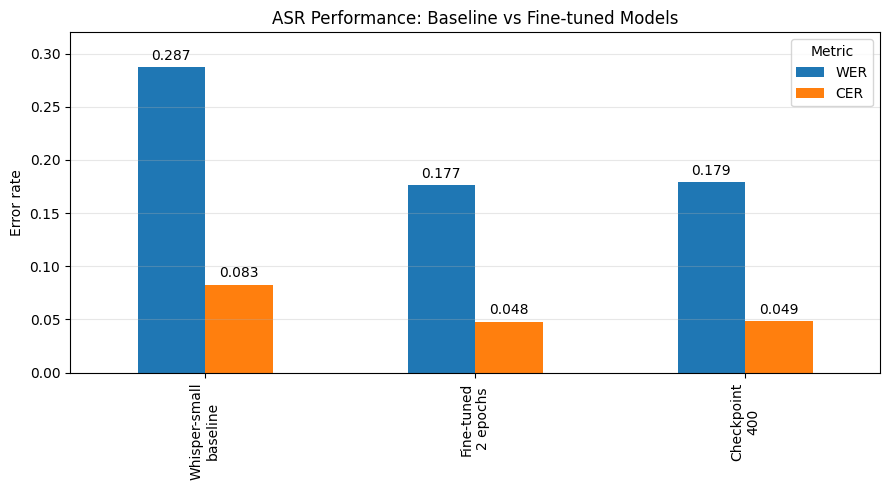

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.DataFrame([
    {
        "model": "Whisper-small\nbaseline",
        "WER": 0.2870,
        "CER": 0.0828,
    },
    {
        "model": "Fine-tuned\n2 epochs",
        "WER": 0.17656988521269412,
        "CER": 0.04804532577903683,
    },
    {
        "model": "Checkpoint\n400",
        "WER": 0.1789,
        "CER": 0.0487,
    },
])

ax = metrics.set_index("model")[["WER", "CER"]].plot(kind="bar", figsize=(9, 5))

ax.set_title("ASR Performance: Baseline vs Fine-tuned Models")
ax.set_ylabel("Error rate")
ax.set_xlabel("")
ax.set_ylim(0, 0.32)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_vs_finetuned_wer_cer.png", dpi=300)
plt.show()

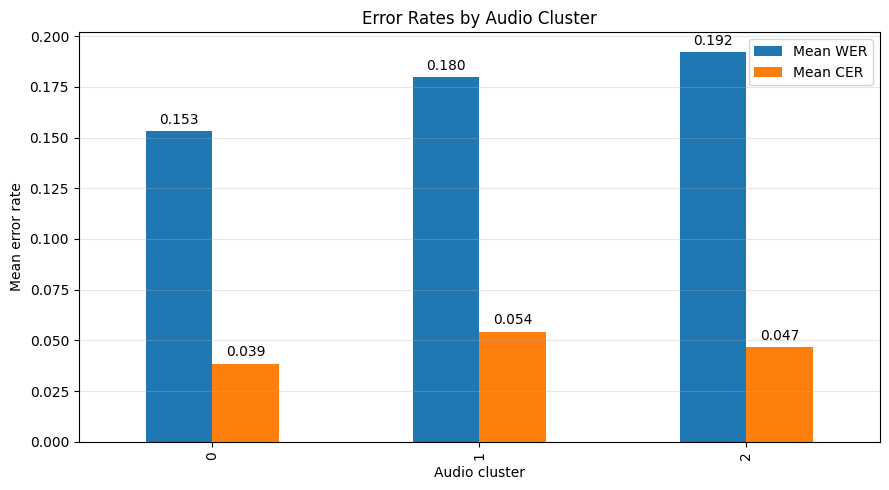

In [40]:
audio_cluster_df = pd.read_csv(
    "results/error_analysis_finetuned_2epochs_stopwords_k3/error_summary_by_audio_cluster.csv"
)

audio_cluster_df = audio_cluster_df.sort_values("audio_cluster")

ax = audio_cluster_df.set_index("audio_cluster")[["mean_wer", "mean_cer"]].plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Error Rates by Audio Cluster")
ax.set_ylabel("Mean error rate")
ax.set_xlabel("Audio cluster")
ax.grid(axis="y", alpha=0.3)
ax.legend(["Mean WER", "Mean CER"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "audio_cluster_wer_cer.png", dpi=300)
plt.show()

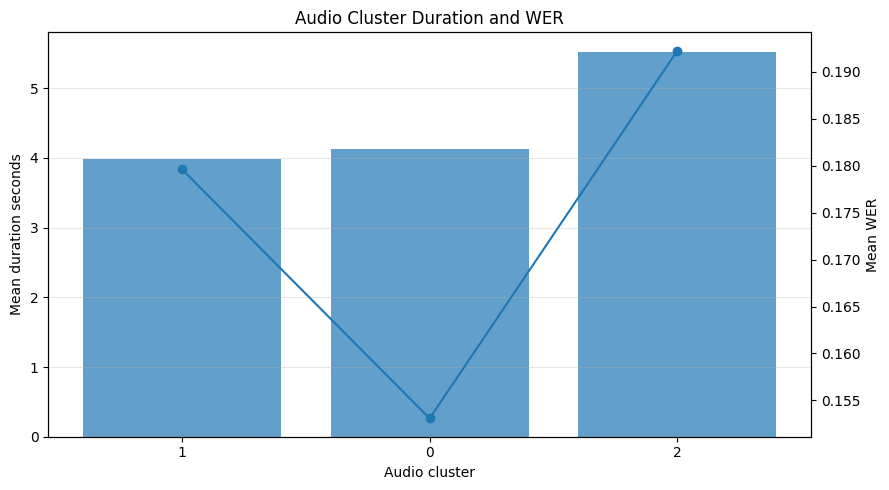

In [41]:
audio_cluster_df = audio_cluster_df.sort_values("mean_duration_seconds")

fig, ax1 = plt.subplots(figsize=(9, 5))

x = range(len(audio_cluster_df))
labels = audio_cluster_df["audio_cluster"].astype(str)

ax1.bar(x, audio_cluster_df["mean_duration_seconds"], alpha=0.7)
ax1.set_ylabel("Mean duration seconds")
ax1.set_xlabel("Audio cluster")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Audio Cluster Duration and WER")

ax2 = ax1.twinx()
ax2.plot(x, audio_cluster_df["mean_wer"], marker="o")
ax2.set_ylabel("Mean WER")

ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "audio_cluster_duration_vs_wer.png", dpi=300)
plt.show()

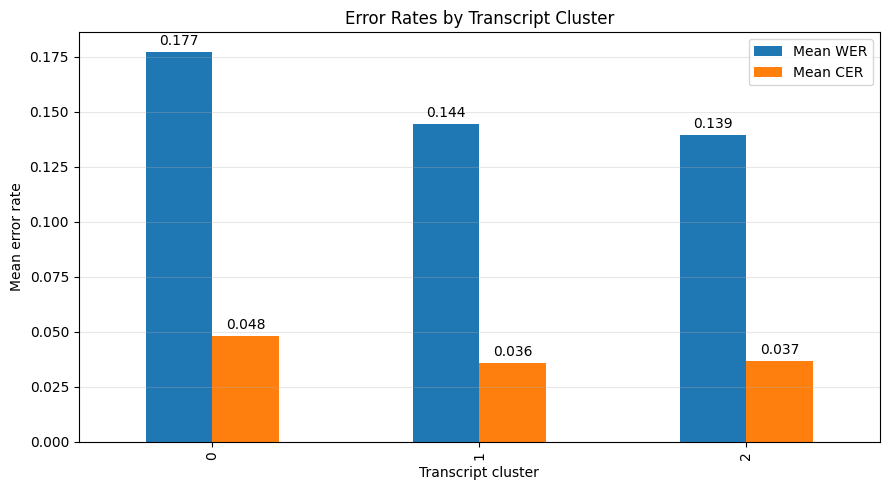

In [42]:
text_cluster_df = pd.read_csv(
    "results/error_analysis_finetuned_2epochs_stopwords_k3/error_summary_by_text_cluster.csv"
)

text_cluster_df = text_cluster_df.sort_values("text_cluster_stopwords")

ax = text_cluster_df.set_index("text_cluster_stopwords")[["mean_wer", "mean_cer"]].plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Error Rates by Transcript Cluster")
ax.set_ylabel("Mean error rate")
ax.set_xlabel("Transcript cluster")
ax.grid(axis="y", alpha=0.3)
ax.legend(["Mean WER", "Mean CER"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_cluster_k3_wer_cer.png", dpi=300)
plt.show()

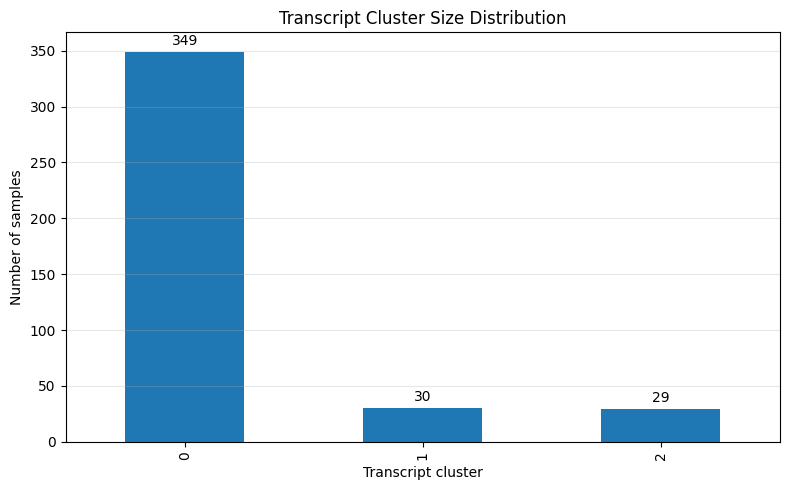

In [43]:
ax = text_cluster_df.set_index("text_cluster_stopwords")["samples"].plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Transcript Cluster Size Distribution")
ax.set_ylabel("Number of samples")
ax.set_xlabel("Transcript cluster")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_cluster_k3_sizes.png", dpi=300)
plt.show()

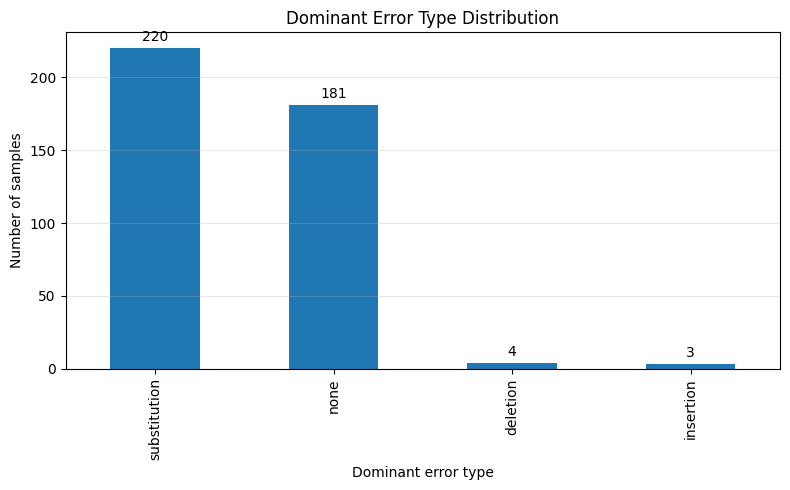

In [44]:
per_sample_errors = pd.read_csv(
    "results/error_analysis_finetuned_2epochs_stopwords_k3/per_sample_errors.csv"
)

error_counts = per_sample_errors["dominant_error"].value_counts().reset_index()
error_counts.columns = ["dominant_error", "samples"]

ax = error_counts.set_index("dominant_error")["samples"].plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Dominant Error Type Distribution")
ax.set_ylabel("Number of samples")
ax.set_xlabel("Dominant error type")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dominant_error_distribution.png", dpi=300)
plt.show()

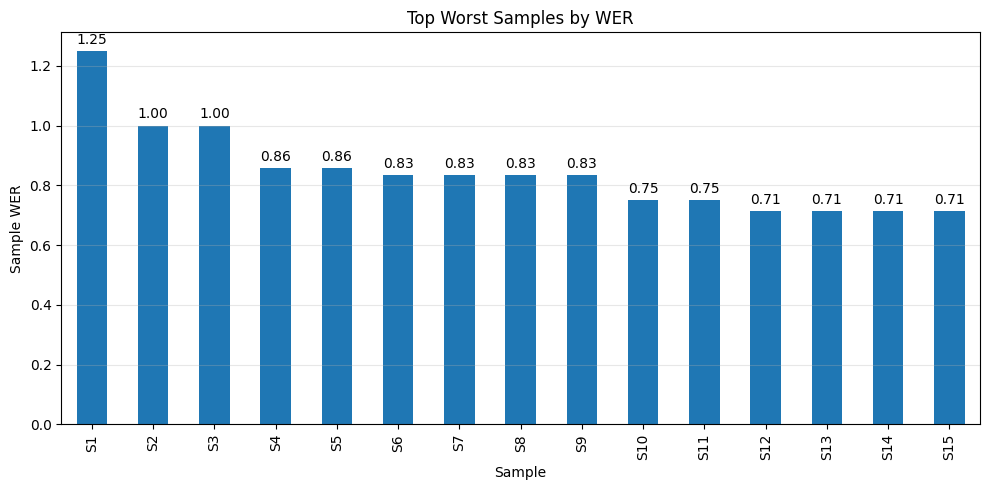

,sample_id,reference,prediction,sample_wer,sample_cer
0,S1,elicopterul nu fusese anunțat,ericopterul nu puse să se anunță,1.250000,0.275862
1,S2,căutăm noi actori pentru a extinde baza,cotăm un actor pentru o acestini de bază,1.000000,0.333333
2,S3,aceste chestiuni țin de competența noastră,ar acestei chestiuni din lecompetența moastră,1.000000,0.190476
3,S4,planeta ne transmite un semnal de alarmă,planeta a intratzmuit în semnul alarma,0.857143,0.350000
4,S5,dubarbier cluj expediază primul șut pe poartă,dui barbieri cluji expediază primul șud pe poa...,0.857143,0.200000
5,S6,iti promit ca vei primi dreptate,eți promit că vă-i primit dreptată,0.833333,0.218750
6,S7,iti poruncesc sa bei niste apa,iti porunce să bein niște apă,0.833333,0.200000
7,S8,tricolorii vor întâlni sâmbătă reprezentativa ...,tricolorii volântâni să îmbătă reprezentativă ...,0.833333,0.166667
8,S9,legislația actuală în vigoare permite derogări,regislația actuală învigua re permite de rogări,0.833333,0.108696
9,S10,nu așa îmi imaginez eu politica de azil,nașa mi-a mai jnezut o politica de azi,0.750000,0.358974


In [45]:
worst_samples = pd.read_csv(
    "results/error_analysis_finetuned_2epochs_stopwords_k3/worst_samples.csv"
)

top_n = 15
plot_df = worst_samples.head(top_n).copy()
plot_df["sample_id"] = [f"S{i+1}" for i in range(len(plot_df))]

ax = plot_df.set_index("sample_id")["sample_wer"].plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("Top Worst Samples by WER")
ax.set_ylabel("Sample WER")
ax.set_xlabel("Sample")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_worst_samples_by_wer.png", dpi=300)
plt.show()

plot_df[["sample_id", "reference", "prediction", "sample_wer", "sample_cer"]]

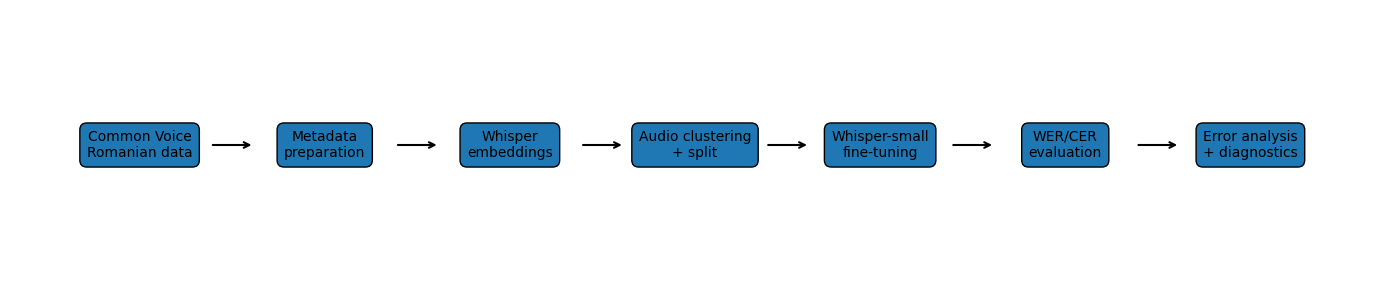

In [46]:
import matplotlib.pyplot as plt

steps = [
    "Common Voice\nRomanian data",
    "Metadata\npreparation",
    "Whisper\nembeddings",
    "Audio clustering\n+ split",
    "Whisper-small\nfine-tuning",
    "WER/CER\nevaluation",
    "Error analysis\n+ diagnostics",
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

x_positions = list(range(len(steps)))

for i, step in enumerate(steps):
    ax.text(
        i,
        0,
        step,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", linewidth=1),
        fontsize=10,
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(i + 0.62, 0),
            xytext=(i + 0.38, 0),
            arrowprops=dict(arrowstyle="->", linewidth=1.5),
        )

ax.set_xlim(-0.7, len(steps) - 0.3)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "project_pipeline_diagram.png", dpi=300)
plt.show()

In [47]:
!mkdir -p /content/drive/MyDrive/romanian-asr-results/evaluation/figures
!cp results/figures/*.png /content/drive/MyDrive/romanian-asr-results/evaluation/figures/

!ls -lh /content/drive/MyDrive/romanian-asr-results/evaluation/figures/

total 826K
-rw------- 1 root root 130K May 12 07:13 audio_cluster_duration_vs_wer.png
-rw------- 1 root root 112K May 12 07:13 audio_cluster_wer_cer.png
-rw------- 1 root root 124K May 12 07:13 baseline_vs_finetuned_wer_cer.png
-rw------- 1 root root  86K May 12 07:13 dominant_error_distribution.png
-rw------- 1 root root  88K May 12 07:13 project_pipeline_diagram.png
-rw------- 1 root root  81K May 12 07:13 text_cluster_k3_sizes.png
-rw------- 1 root root 108K May 12 07:13 text_cluster_k3_wer_cer.png
-rw------- 1 root root  97K May 12 07:13 top_worst_samples_by_wer.png


In [48]:
!python src/select_k_for_text_clustering.py \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --output-dir results/text_k_selection_stopwords \
  --min-k 2 \
  --max-k 12 \
  --min-cluster-samples 20 \
  --max-balance-ratio 15

Evaluating k=2
Evaluating k=3
Evaluating k=4
Evaluating k=5
Evaluating k=6
Evaluating k=7
Evaluating k=8
Evaluating k=9
Evaluating k=10
Evaluating k=11
Evaluating k=12

K selection summary:
 k  silhouette_cosine_mean  silhouette_cosine_std  stability_ari_mean  stability_ari_std  min_cluster_samples_mean  min_cluster_samples_min  max_cluster_samples_mean  balance_ratio_mean  passes_size_constraints  error_cluster_coverage_mean  wer_spread_mean  min_cluster_mean_wer_mean  max_cluster_mean_wer_mean  silhouette_score_norm  stability_score_norm  min_cluster_size_score_norm  balance_score_norm  practical_score  practical_score_with_constraints
 2                0.007350               0.000256            1.000000           0.000000                350.000000                      350               3937.000000           11.248571                     True                          1.0         0.040807                   0.134473                   0.175279               0.000000              1.00000

In [49]:
!cat results/text_k_selection_stopwords/text_k_selection_summary.csv
!cat results/text_k_selection_stopwords/text_k_selection_top_terms.csv

k,silhouette_cosine_mean,silhouette_cosine_std,stability_ari_mean,stability_ari_std,min_cluster_samples_mean,min_cluster_samples_min,max_cluster_samples_mean,balance_ratio_mean,passes_size_constraints,error_cluster_coverage_mean,wer_spread_mean,min_cluster_mean_wer_mean,max_cluster_mean_wer_mean,silhouette_score_norm,stability_score_norm,min_cluster_size_score_norm,balance_score_norm,practical_score,practical_score_with_constraints
2,0.007349671997908323,0.00025595460499279433,1.0,0.0,350.0,350,3937.0,11.248571428571429,True,1.0,0.040806712135966844,0.1344726062467998,0.17527931838276664,0.0,1.0,1.0,1.0,0.65,0.65
11,0.020586279649642106,0.0007539855407180868,0.47444799898659823,0.06419660261236065,46.666666666666664,43,3243.6666666666665,70.07883787186113,False,1.0,0.17844303869003472,0.01870748299319728,0.19715052168323197,0.7935588520484813,0.09856353093247783,0.09970674486803519,0.6898645491977324,0.4603007397632415,0.23015036988162074
8,0.017148845974396486,0.0028243757486947564,0.

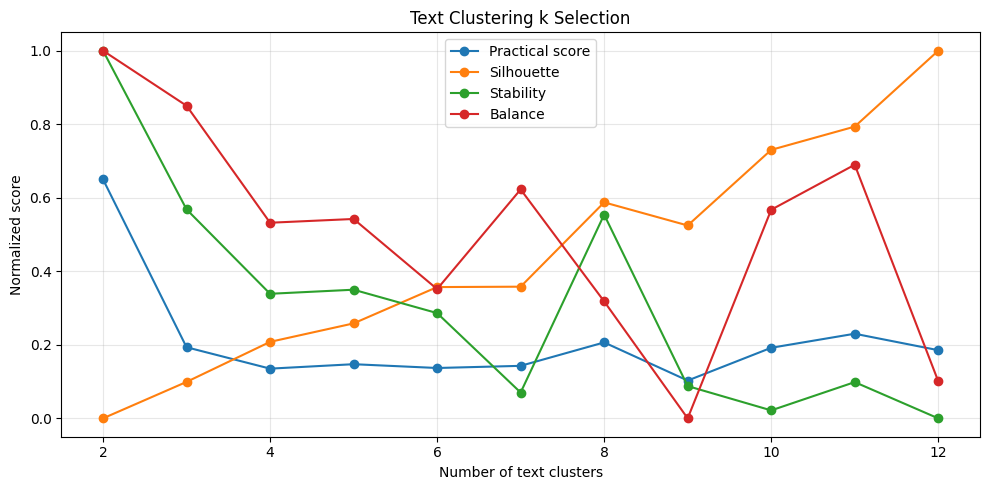

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

k_df = pd.read_csv("results/text_k_selection_stopwords/text_k_selection_summary.csv")
k_df = k_df.sort_values("k")

ax = k_df.set_index("k")[[
    "practical_score_with_constraints",
    "silhouette_score_norm",
    "stability_score_norm",
    "balance_score_norm",
]].plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
)

ax.set_title("Text Clustering k Selection")
ax.set_xlabel("Number of text clusters")
ax.set_ylabel("Normalized score")
ax.grid(alpha=0.3)
ax.legend([
    "Practical score",
    "Silhouette",
    "Stability",
    "Balance",
])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_clustering_k_selection_scores.png", dpi=300)
plt.show()

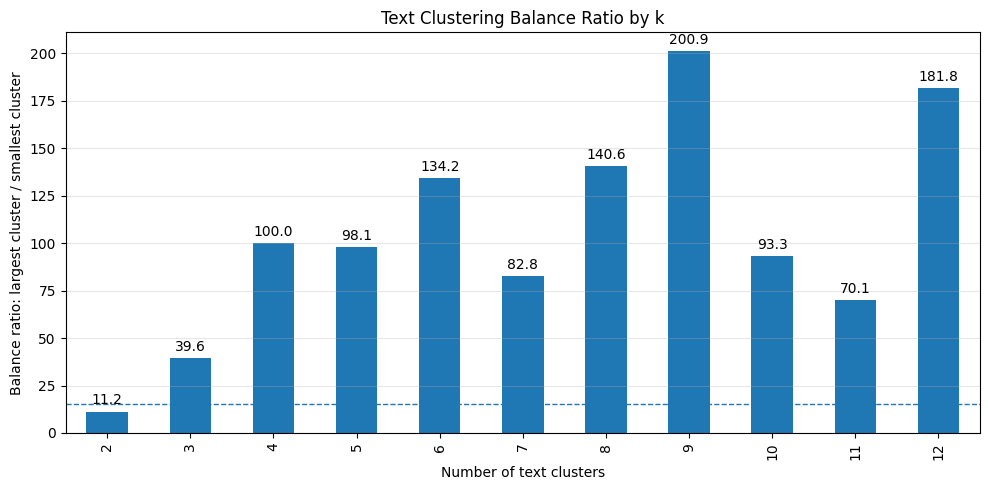

In [51]:
ax = k_df.set_index("k")["balance_ratio_mean"].plot(
    kind="bar",
    figsize=(10, 5),
)

ax.axhline(15, linestyle="--", linewidth=1)
ax.set_title("Text Clustering Balance Ratio by k")
ax.set_xlabel("Number of text clusters")
ax.set_ylabel("Balance ratio: largest cluster / smallest cluster")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_clustering_k_balance_ratio.png", dpi=300)
plt.show()

In [52]:
!pip install -q sentence-transformers

In [53]:
!python src/analyze_asr_errors_sentence_embeddings.py \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --output-dir results/error_analysis_sentence_embeddings \
  --min-k 2 \
  --max-k 10

Using device for sentence embeddings: cuda
Loading sentence embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
modules.json: 100% 229/229 [00:00<00:00, 678kB/s]
config_sentence_transformers.json: 100% 122/122 [00:00<00:00, 514kB/s]
README.md: 3.89kB [00:00, 9.28MB/s]
sentence_bert_config.json: 100% 53.0/53.0 [00:00<00:00, 330kB/s]
config.json: 100% 645/645 [00:00<00:00, 2.67MB/s]
model.safetensors: 100% 471M/471M [00:02<00:00, 173MB/s]
Loading weights: 100% 199/199 [00:00<00:00, 900.46it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
tokenizer_config.json: 100% 526/526 [00:00<00:00, 2.94MB/s]
tokenizer.json: 100% 9.08M/9.08M [00:00

In [54]:
!cat results/error_analysis_sentence_embeddings/sentence_k_selection_summary.csv
!cat results/error_analysis_sentence_embeddings/error_summary_by_sentence_cluster.csv
!cat results/error_analysis_sentence_embeddings/top_terms_per_sentence_cluster.csv
!head -30 results/error_analysis_sentence_embeddings/representative_samples_per_sentence_cluster.csv

k,silhouette_cosine_mean,silhouette_cosine_std,stability_ari_mean,stability_ari_std,min_cluster_samples_mean,min_cluster_samples_min,max_cluster_samples_mean,balance_ratio_mean,passes_size_constraints,error_cluster_coverage_mean,wer_spread_mean,min_cluster_mean_wer_mean,max_cluster_mean_wer_mean,silhouette_score_norm,stability_score_norm,min_cluster_size_score_norm,balance_score_norm,practical_score,practical_score_with_constraints
2,0.11225864787896474,0.0016076538389276868,0.9981294452564563,0.0013226819437403843,1648.0,1646,2639.0,1.6013368682518292,True,1.0,0.03637000682349517,0.158807482353994,0.1951774891774892,1.0,1.0,1.0,0.8910847119256152,0.9782169423851231,0.9782169423851231
3,0.07763459781805675,0.0011451634193969996,0.9718385665960749,0.002100905970211473,1286.6666666666667,1276,1627.0,1.2646086322126362,True,1.0,0.04254367206111697,0.1586413209031028,0.20118499296421977,0.35544854191650116,0.943472437175441,0.7572178477690289,0.9820531780158133,0.708129304121604,0.70812930

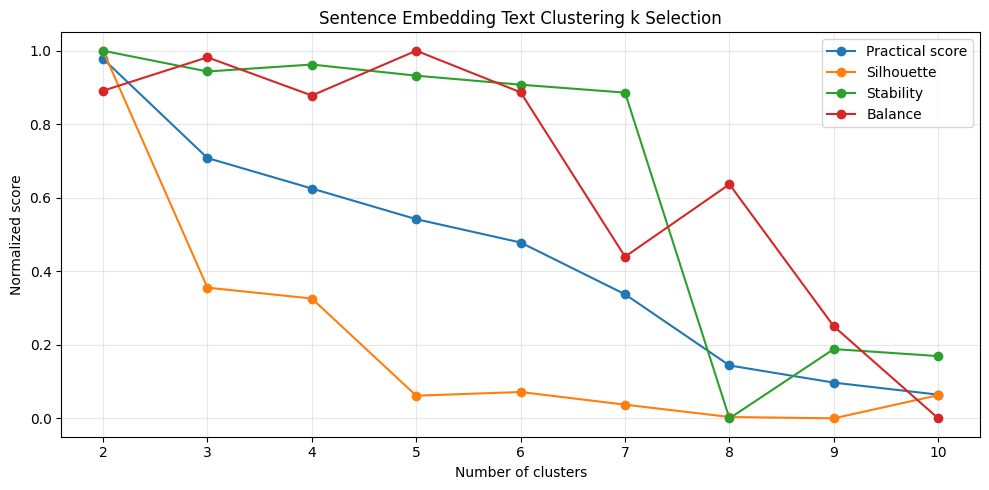

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

k_df = pd.read_csv("results/error_analysis_sentence_embeddings/sentence_k_selection_summary.csv")
k_df = k_df.sort_values("k")

ax = k_df.set_index("k")[[
    "practical_score_with_constraints",
    "silhouette_score_norm",
    "stability_score_norm",
    "balance_score_norm",
]].plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
)

ax.set_title("Sentence Embedding Text Clustering k Selection")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Normalized score")
ax.grid(alpha=0.3)
ax.legend([
    "Practical score",
    "Silhouette",
    "Stability",
    "Balance",
])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentence_embedding_k_selection_scores.png", dpi=300)
plt.show()

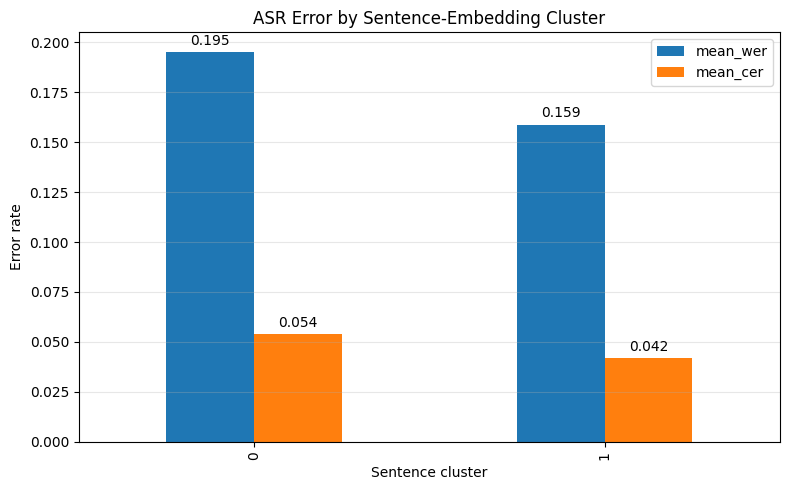

In [56]:
summary_df = pd.read_csv(
    "results/error_analysis_sentence_embeddings/error_summary_by_sentence_cluster.csv"
)

ax = summary_df.set_index("sentence_cluster")[["mean_wer", "mean_cer"]].plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("ASR Error by Sentence-Embedding Cluster")
ax.set_xlabel("Sentence cluster")
ax.set_ylabel("Error rate")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentence_cluster_wer_cer.png", dpi=300)
plt.show()

In [57]:
!python src/analyze_audio_quality_errors.py \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --sentence-clusters-csv results/error_analysis_sentence_embeddings/sentence_cluster_assignments.csv \
  --output-dir results/audio_quality_analysis_smoke \
  --max-samples 20

Analyzing audio files: 20

Overall audio quality analysis:
                               predictions_file                                       metadata_file  samples  skipped_samples  overall_wer  overall_cer  mean_sample_wer  mean_sample_cer  mean_duration_seconds  mean_words_per_second  mean_rms_db  mean_silence_ratio  mean_snr_proxy_db  compute_pitch
results/finetuned_predictions_2epochs_final.csv data/processed/metadata_with_clusters_and_split.csv       20                0     0.190141     0.044258         0.191845         0.044096                 4.5516                1.58089   -29.693005            0.295397          51.307153          False

Top audio feature correlations with WER:
                feature  pearson_corr_with_wer  spearman_corr_with_wer  pearson_corr_with_cer  spearman_corr_with_cer  samples  abs_spearman_corr_with_wer
  spectral_rolloff_mean              -0.334845               -0.421047              -0.378982               -0.480910       20                    

In [58]:
!python src/analyze_audio_quality_errors.py \
  --predictions-csv results/finetuned_predictions_2epochs_final.csv \
  --metadata-csv data/processed/metadata_with_clusters_and_split.csv \
  --sentence-clusters-csv results/error_analysis_sentence_embeddings/sentence_cluster_assignments.csv \
  --output-dir results/audio_quality_analysis

Analyzing audio files: 408
Processed 50/408
Processed 100/408
Processed 150/408
Processed 200/408
Processed 250/408
Processed 300/408
Processed 350/408
Processed 400/408

Overall audio quality analysis:
                               predictions_file                                       metadata_file  samples  skipped_samples  overall_wer  overall_cer  mean_sample_wer  mean_sample_cer  mean_duration_seconds  mean_words_per_second  mean_rms_db  mean_silence_ratio  mean_snr_proxy_db  compute_pitch
results/finetuned_predictions_2epochs_final.csv data/processed/metadata_with_clusters_and_split.csv      408                0      0.17657     0.048045         0.172179         0.046294               4.404235               1.692255   -26.862794            0.346533          66.644772          False

Top audio feature correlations with WER:
                feature  pearson_corr_with_wer  spearman_corr_with_wer  pearson_corr_with_cer  spearman_corr_with_cer  samples  abs_spearman_corr_with_wer
 s

In [59]:
!cat results/audio_quality_analysis/overall_audio_quality_metrics.csv
!cat results/audio_quality_analysis/audio_feature_correlations.csv | head -25
!cat results/audio_quality_analysis/error_by_audio_cluster.csv
!cat results/audio_quality_analysis/error_by_sentence_cluster.csv
!cat results/audio_quality_analysis/error_by_duration_bucket.csv
!cat results/audio_quality_analysis/error_by_audio_and_sentence_cluster.csv
!head -30 results/audio_quality_analysis/worst_samples_with_audio_features.csv

predictions_file,metadata_file,samples,skipped_samples,overall_wer,overall_cer,mean_sample_wer,mean_sample_cer,mean_duration_seconds,mean_words_per_second,mean_rms_db,mean_silence_ratio,mean_snr_proxy_db,compute_pitch
results/finetuned_predictions_2epochs_final.csv,data/processed/metadata_with_clusters_and_split.csv,408,0,0.17656988521269412,0.04804532577903683,0.17217880839204366,0.04629416259514587,4.404235294117647,1.692255470972218,-26.862794341182923,0.34653286472397304,66.64477194966832,False
feature,pearson_corr_with_wer,spearman_corr_with_wer,pearson_corr_with_cer,spearman_corr_with_cer,samples,abs_spearman_corr_with_wer
spectral_centroid_mean,-0.16690178717656012,-0.19701591566897372,-0.21038490944388016,-0.20679233061877864,408,0.19701591566897372
spectral_rolloff_mean,-0.15872908553362036,-0.194777821072436,-0.19299398515893504,-0.1985224091897848,408,0.194777821072436
mfcc_2_std,0.16699561600850807,0.19382626755688914,0.11603481785874788,0.16402177286799596,408,0.1938262675

In [60]:
!cp -r results/audio_quality_analysis \
  /content/drive/MyDrive/romanian-asr-results/evaluation/